### Creating input-target pairs

In this section we will implement a data loader that fetches the inut-target pairs using a sliding window approach

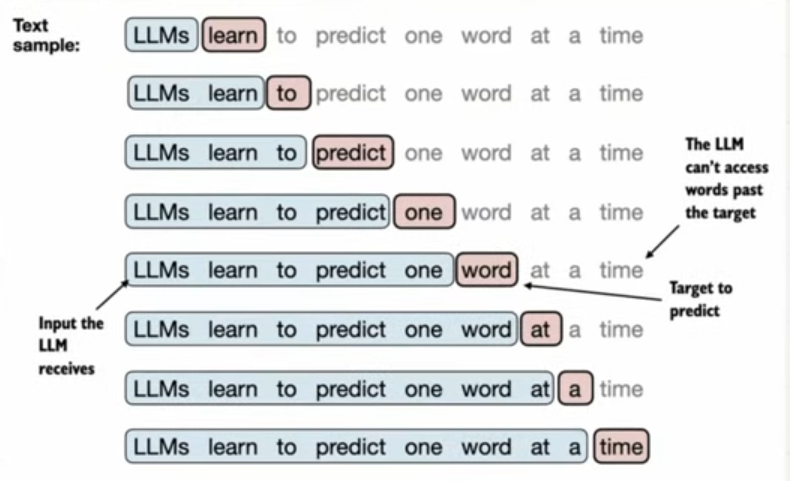

In [1]:
from IPython.display import Image
Image("images/input_target_pairs.png")

To start, we will first tokenize the whole "TEXT" using the BPE tokenizer

In [1]:
import tiktoken

In [2]:
tokenizer = tiktoken.get_encoding("gpt2")

In [3]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()


enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


The above text has 5145 token, after applying BPE tokenizer

In [5]:
enc_sample = enc_text[50:]

One of the easiste ways to create the input-target pairs for the nextword prediction task is to create 2 variables x & y

Where x contains input & y contains target, which are inputs shifted by 1

The "CONTEXT SIZE" determines how many tokens are included in the input

In [8]:
context_size = 4

# the context size of 4 means that the model will look at the previous 4 tokens to predict the next token

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:     {y}")

x: [290, 4920, 2241, 287]
y:     [4920, 2241, 287, 257]


Processing inputs along with the target, which are inputs shifted by one position , we can then create then create the next word prediction target

In [9]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    target = enc_sample[i]
    
    print(context, "----->", target) 

[290] -----> 4920
[290, 4920] -----> 2241
[290, 4920, 2241] -----> 287
[290, 4920, 2241, 287] -----> 257


Left size of arrow "----->"  refers to an input an LLM would receive, and the token ID on the right side of arrow represents the target token ID, that the LLM is supposed to predict

In [10]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    target = enc_sample[i]
    
    print(tokenizer.decode(context), "----->", tokenizer.decode([target])) 

 and ----->  established
 and established ----->  himself
 and established himself ----->  in
 and established himself in ----->  a


There is one more task before we can turn the tokens into embeddings: implementing an efficient data loader, that iterates over the input dataset and return the input and target Pytorch tensors, which can be thought of as multidimensional arrays.